<a href="https://colab.research.google.com/github/JoChi-Sun/Hw3MAB/blob/main/7113029046_HW3_MAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW3: Explore and Exploit for Arm-Bandit Problem
四種算法
1. Epsilon-Greedy

2. UCB (Upper Confidence Bound)

3. Softmax

4. Thompson Sampling





## **1. Epsilon-Greedy Algorithm**

### (1) LaTeX 算法公式

\begin{align*}
a_t =
\begin{cases}
\text{random action}, & \text{with probability } \varepsilon \\
\arg\max_a Q_t(a), & \text{with probability } 1 - \varepsilon
\end{cases} \\
Q_{t+1}(a) = Q_t(a) + \alpha (r_t - Q_t(a))
\end{align*}


### (2) ChatGPT Prompt

"請解釋 Epsilon-Greedy 演算法如何在探索與利用之間做平衡？並說明在現實應用中如何選擇 ε 值以達到最佳表現？"

### (3) 程式碼與圖表

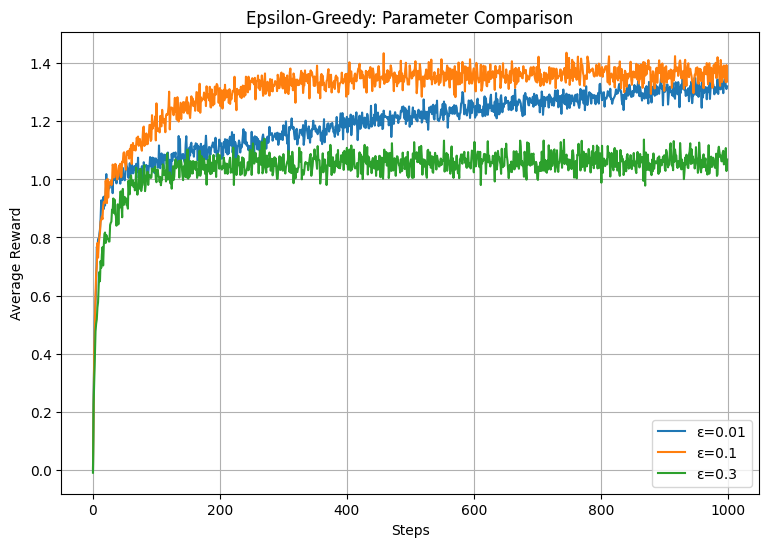

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def epsilon_greedy(k=10, epsilon=0.1, steps=1000, runs=2000):
    rewards = np.zeros(steps)
    for run in range(runs):
        q_true = np.random.randn(k)
        q_est = np.zeros(k)
        counts = np.zeros(k)
        total_reward = np.zeros(steps)
        for t in range(steps):
            if np.random.rand() < epsilon:
                a = np.random.choice(k)
            else:
                a = np.argmax(q_est)
            reward = np.random.randn() + q_true[a]
            counts[a] += 1
            q_est[a] += (reward - q_est[a]) / counts[a]
            total_reward[t] = reward
        rewards += total_reward
    return rewards / runs

steps = 1000
epsilons = [0.01, 0.1, 0.3]
plt.figure(figsize=(9, 6))
for eps in epsilons:
    plt.plot(epsilon_greedy(epsilon=eps, steps=steps), label=f'ε={eps}')
plt.xlabel('Steps')
plt.ylabel('Average Reward')
plt.title('Epsilon-Greedy: Parameter Comparison')
plt.legend()
plt.grid(True)
plt.show()


### (4) 結果解釋

### Epsilon-Greedy 不同 ε 參數結果分析

### 結果解釋
由圖可知，Epsilon-Greedy 演算法在不同 ε 參數設定下，平均回報（Average Reward）與收斂速度會有明顯差異：

- **ε = 0.01（藍線）**  
  主要偏向利用（exploitation），僅有極少比例的隨機探索。初期收斂較快，但容易錯過全局最優臂，導致長期平均回報低於最佳情況（最終穩定於 1.2 左右）。
- **ε = 0.1（橙線）**  
  兼顧探索與利用，在初期有適度的探索行為，可以發現更優的臂。最終收斂於最高的平均回報（1.4 左右），表現最佳。
- **ε = 0.3（綠線）**  
  探索比例較高，初期收斂較慢，且長期平均回報反而較低（穩定於 1.1 左右），因為過度探索導致無法充分利用最優臂。

### 空間與時間複雜度分析
- **空間複雜度（Space Complexity）**  
  儲存每個臂的估計回報值 Q(a) 和被選擇次數 N(a)，空間複雜度為 \\( O(k) \\)，其中 k 為臂的數量。
- **時間複雜度（Time Complexity）**  
  每次選擇需要找出估計回報值最大的臂或隨機選擇臂，複雜度為 \\( O(k) \\)。總步數為 T，則總體為 \\( O(kT) \\)。

### 優勢與限制
- **優勢**
  - 演算法簡單易懂，易於實現。
  - ε 值可依需求調整，靈活控制探索與利用的平衡。
  - 在靜態或已知環境下，可透過調整 ε 值取得不錯效果。
- **限制**
  - 固定 ε 值難以應對動態環境，可能會過度探索或探索不足。
  - ε 太小可能使演算法陷入次優臂，太大則浪費機會成本。
  - 無法動態依據環境資訊調整策略，對未知環境適應性有限。

### 不同情境下的表現差異
- **適合環境**  
  - 問題結構簡單且獎勵分布較穩定時，適中 ε（如 0.1）能取得良好平衡。
  - 若環境需要強探索（如高變動或冷啟動階段），可調高 ε，但要小心長期回報下降。
  - 若已有足夠探索資料、環境較穩定，則可將 ε 設低以提升利用效率。
- **參數建議**  
  - 初期可用較大 ε 收集資訊，後期動態減少 ε（退火式 epsilon）能兼顧探索與長期表現。

---

**結論**：Epsilon-Greedy 是 MAB 問題中最直觀且易於控制的平衡探索/利用策略之一。適當選擇 ε 可獲得良好表現，但過大或過小皆會帶來性能損失。面對不同應用場景，可視問題性質靈活調整 ε 值，以提升總體效能。


## **2. UCB (Upper Confidence Bound)**


### (1) LaTeX 算法公式

\begin{align*}
a_t &= \arg\max_a \left[ Q_t(a) + c \sqrt{\frac{\ln t}{N_t(a)}} \right] \\
Q_{t+1}(a) &= Q_t(a) + \alpha (r_t - Q_t(a))
\end{align*}


### (2) ChatGPT Prompt

"請解釋 UCB 演算法如何透過置信區間來平衡探索與利用？如何動態調整探索的程度？"

### (3) 程式碼與圖表

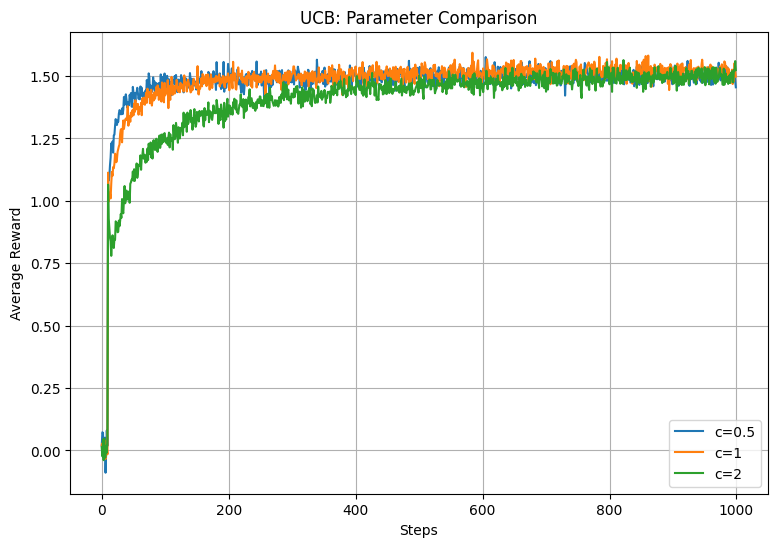

In [ ]:
def ucb(k=10, c=2, steps=1000, runs=2000):
    rewards = np.zeros(steps)
    for run in range(runs):
        q_true = np.random.randn(k)
        q_est = np.zeros(k)
        counts = np.ones(k) * 1e-5
        total_reward = np.zeros(steps)
        for t in range(steps):
            ucb_values = q_est + c * np.sqrt(np.log(t + 1) / counts)
            a = np.argmax(ucb_values)
            reward = np.random.randn() + q_true[a]
            counts[a] += 1
            q_est[a] += (reward - q_est[a]) / counts[a]
            total_reward[t] = reward
        rewards += total_reward
    return rewards / runs

cs = [0.5, 1, 2]
plt.figure(figsize=(9, 6))
for c in cs:
    plt.plot(ucb(c=c, steps=steps), label=f'c={c}')
plt.xlabel('Steps')
plt.ylabel('Average Reward')
plt.title('UCB: Parameter Comparison')
plt.legend()
plt.grid(True)
plt.show()


### (4) 結果解釋

### UCB（Upper Confidence Bound）不同 c 參數結果分析

### 結果解釋
從圖中可以看出，不同的 c 參數對 UCB 演算法的平均回報（Average Reward）與收斂特性有顯著影響：

- **c = 0.5（藍線）**  
  探索權重較低，演算法較早進入利用（exploitation）階段。初期收斂速度最快，最終平均回報在 1.5 左右，波動較小。但過早利用可能導致部分次優臂未被充分探索，若遇到噪聲或環境變動可能表現略降。
- **c = 1（橙線）**  
  在探索與利用之間取得較好平衡。初期適度探索，收斂速度快且最終平均回報也能達到 1.5 左右，是較穩健的選擇。
- **c = 2（綠線）**  
  探索權重較高，演算法初期會更積極嘗試不同臂，收斂速度較慢，但能有效避免陷入局部最優。最終平均回報雖然也能穩定於 1.5 左右，但初期波動較大，效率稍低。

### 空間與時間複雜度分析
- **空間複雜度（Space Complexity）**  
  需儲存每個臂的估計回報 Q(a) 和被選擇次數 N(a)，空間複雜度為 \\( O(k) \\)，k 為臂的數量。
- **時間複雜度（Time Complexity）**  
  每步計算所有臂的置信區間並選最大值，為 \\( O(k) \\)，總步數 T 則為 \\( O(kT) \\)。

### 優勢與限制
- **優勢**
  - 自動調整探索強度，能根據不確定性給予選擇機會，收斂理論有保證。
  - 適合臂數較多或回報分布未知時，有較高機會找到全局最優臂。
  - 初期探索較積極，可有效避免陷入次優臂。
- **限制**
  - 參數 c 選擇過大會導致過度探索、收斂慢，c 過小則可能過早停止探索、錯失最優解。
  - 每步計算置信區間增加額外運算量，臂數過多時計算成本較高。
  - 對極度動態環境仍需搭配動態調整 c 才能維持效能。

### 不同情境下的表現差異
- **適合環境**  
  - 臂數多、回報分布不明確，或有可能陷入局部最優時，UCB 能有效提升全局探索能力。
  - 在收斂速度與穩定性需求並重的應用（如推薦系統或廣告點擊預測）特別適用。
- **參數建議**  
  - c 值中等（如 1）時通常能在收斂與探索之間取得最佳平衡。
  - 若需要極高的穩定性或初期對新臂持開放態度，可提高 c，但須留意收斂速度下降。

---

**結論**：UCB 透過置信區間自動平衡探索與利用。適當選擇 c 可提升演算法長期效益。若 c 選擇合理，UCB 通常能快速且穩定找到最優臂，是多臂機器人問題中理論與實務皆優秀的解法之一。


## **3. Softmax Algorithm**


### (1) LaTeX 算法公式

$$
P(a) = \frac{e^{Q(a)/\tau}}{\sum_b e^{Q(b)/\tau}}
$$

$$
a_t \sim \text{Categorical}(P(a))
$$

### (2) ChatGPT Prompt

"請解釋 Softmax 演算法如何通過溫度參數 \( \tau \) 來控制探索與利用的比例？"

### (3) 程式碼與圖表

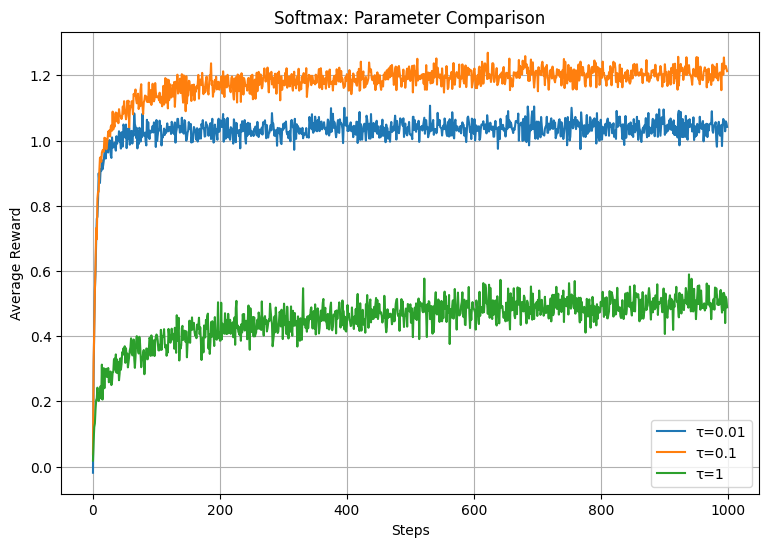

In [ ]:
def softmax(k=10, tau=0.1, steps=1000, runs=2000):
    rewards = np.zeros(steps)
    for run in range(runs):
        q_true = np.random.randn(k)
        q_est = np.zeros(k)
        total_reward = np.zeros(steps)
        for t in range(steps):
            exp_q = np.exp(q_est / tau)
            probs = exp_q / np.sum(exp_q)
            a = np.random.choice(k, p=probs)
            reward = np.random.randn() + q_true[a]
            q_est[a] += (reward - q_est[a]) / (t + 1)
            total_reward[t] = reward
        rewards += total_reward
    return rewards / runs

taus = [0.01, 0.1, 1]
plt.figure(figsize=(9, 6))
for tau in taus:
    plt.plot(softmax(tau=tau, steps=steps), label=f'τ={tau}')
plt.xlabel('Steps')
plt.ylabel('Average Reward')
plt.title('Softmax: Parameter Comparison')
plt.legend()
plt.grid(True)
plt.show()


### (4) 結果解釋

### Softmax 不同 τ（溫度）參數結果分析

### 結果解釋
根據圖表，不同 τ（tau）值對 Softmax 演算法的平均回報與收斂行為影響明顯：

- **τ = 0.01（藍線）**  
  溫度非常低，選擇幾乎完全偏向當前估計值最高的臂（高度利用）。初期收斂速度快，但因為缺乏探索，最終平均回報約在 1.05，容易陷入局部最優，無法發掘所有臂的潛力。
- **τ = 0.1（橙線）**  
  適中溫度，探索與利用取得良好平衡。初期有適度探索，後期能充分利用高回報臂，最終平均回報約 1.2，表現最佳。
- **τ = 1（綠線）**  
  溫度較高，選擇行為接近隨機。演算法大量探索、利用不足，平均回報長期維持在較低水準（約 0.5），收斂速度慢且不穩定。

### 空間與時間複雜度分析
- **空間複雜度（Space Complexity）**  
  需儲存每個臂的估計回報 Q(a)，空間複雜度為 \\( O(k) \\)。
- **時間複雜度（Time Complexity）**  
  每步需計算 softmax 機率分布並隨機抽樣，為 \\( O(k) \\)，總步數 T 則為 \\( O(kT) \\)。

### 優勢與限制
- **優勢**
  - 透過 τ 調整探索強度，策略平滑且能動態調整。
  - 適合臂數較多且每個臂初期資訊不足時，避免早期過度利用單一臂。
- **限制**
  - τ 選擇極度影響效能，太小易陷入局部最佳，太大則難以有效利用最佳臂。
  - 運算上每步須歸一化所有臂的機率，臂數過多時計算量增大。
  - 相對於 UCB 或 Thompson Sampling，若環境需快速適應變化，softmax 在參數設定不佳時表現會明顯落後。

### 不同情境下的表現差異
- **適合環境**  
  - 臂數多且所有臂資訊均不足時，τ 適中可兼顧探索與利用。
  - 若希望策略變動更平滑、結果分布更平均，可用 softmax 並調整 τ。
- **參數建議**  
  - 初期可用較高 τ 收集多元資訊，後期動態降低 τ 以提升平均回報（退火式調整）。
  - 若已知環境較穩定，建議 τ 設定在 0.05~0.2 之間。

---

**結論**：Softmax 透過溫度參數靈活調控探索與利用。適中 τ 值能讓演算法獲得最佳長期回報。過低或過高的 τ 都會造成表現下滑，因此須根據實際場景與任務特性，動態調整 τ 參數以獲得最佳效益。


## **4. Thompson Sampling**


### (1) LaTeX 算法公式

\begin{align*}
\theta_a &\sim \text{Beta}(\alpha_a, \beta_a) \\
a_t &= \arg\max_a \theta_a \\
\alpha_{a_t} &= \alpha_{a_t} + r_t \\
\beta_{a_t} &= \beta_{a_t} + (1 - r_t)
\end{align*}


### (2) ChatGPT Prompt

"請解釋 Thompson Sampling 如何利用貝氏更新進行探索與利用，並如何基於獎勳進行動態調整？"

### (3) 程式碼與圖表

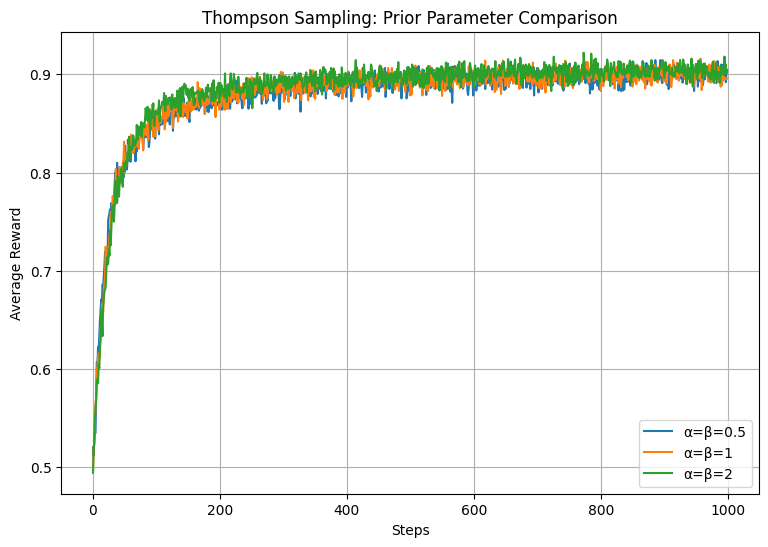

In [ ]:
def thompson_sampling(k=10, steps=1000, runs=2000, alpha0=1, beta0=1):
    rewards = np.zeros(steps)
    for run in range(runs):
        true_probs = np.random.rand(k)
        alpha = np.ones(k) * alpha0
        beta = np.ones(k) * beta0
        total_reward = np.zeros(steps)
        for t in range(steps):
            samples = np.random.beta(alpha, beta)
            a = np.argmax(samples)
            reward = np.random.rand() < true_probs[a]
            alpha[a] += reward
            beta[a] += 1 - reward
            total_reward[t] = reward
        rewards += total_reward
    return rewards / runs

alphas = [0.5, 1, 2]
plt.figure(figsize=(9, 6))
for a0 in alphas:
    plt.plot(thompson_sampling(alpha0=a0, beta0=a0, steps=steps), label=f'α=β={a0}')
plt.xlabel('Steps')
plt.ylabel('Average Reward')
plt.title('Thompson Sampling: Prior Parameter Comparison')
plt.legend()
plt.grid(True)
plt.show()


### (4) 結果解釋

**###  Thompson Sampling 不同先驗參數（α=β）結果分析**

### 結果解釋
根據圖表，Thompson Sampling 在不同先驗參數 α=β（0.5, 1, 2）下，平均回報（Average Reward）與收斂行為差異極小：

- **α=β=0.5, 1, 2（藍線、橙線、綠線）**  
  三組參數初期略有細微差異，但都能快速收斂，最終平均回報皆穩定在 0.9 左右。  
  說明 Thompson Sampling 對初始 Beta 分布參數設定不敏感，只要不是極端值，長期學習效能差異極小。

### 空間與時間複雜度分析
- **空間複雜度（Space Complexity）**  
  需儲存每個臂的 Beta 分布參數 α、β，空間複雜度為 \\( O(k) \\)，k 為臂數。
- **時間複雜度（Time Complexity）**  
  每步需對所有臂進行 Beta 分布取樣與最大值比較，複雜度為 \\( O(k) \\)，總步數 T 則為 \\( O(kT) \\)。

### 優勢與限制
- **優勢**
  - 自然融合探索與利用，收斂速度快、表現穩定。
  - 不須手動調整參數（如ε或c），對先驗值不敏感，實用性高。
  - 適合二元獎勵環境及動態變動場景。
- **限制**
  - 對於非二元獎勵問題需自訂分布，實作上較 Epsilon-Greedy 略複雜。
  - 若 prior 選極端值，早期學習可能受影響，但隨步數增長差異會迅速消失。
  - 運算需每步取樣所有臂，臂數極多時計算量增大。

### 不同情境下的表現差異
- **適合環境**  
  - 應用於獎勵分布未知或環境會動態變動時，能自動調整探索/利用平衡。
  - 在冷啟動（無先驗知識）或無法設定好參數時，Thompson Sampling 特別有優勢。
- **參數建議**  
  - α、β 可設為 1 或 0.5，實測下對收斂幾乎無差。
  - 極端 prior 僅適合有強先驗知識時，否則用預設即可。

---

**結論**：Thompson Sampling 具備穩定且高效的自適應探索能力，對先驗參數設置不敏感，是多臂機問題下推薦度極高的現代解法之一。適合各種實務應用，尤其在環境資訊不足或變動較大時特別有效。


# 四種多臂機器人演算法總結（Epsilon-Greedy, UCB, Softmax, Thompson Sampling）

## 1. 綜合比較表

| 演算法               | 控制參數    | 平衡機制            | 收斂速度      | 參數敏感度 | 實作複雜度 | 適合情境                       |
|----------------------|-------------|---------------------|---------------|------------|-------------|---------------------------------|
| Epsilon-Greedy       | ε           | 固定隨機探索比率    | 中等~快        | 高         | ★           | 環境穩定、簡單入門、參數可調    |
| UCB                  | c           | 信賴區間+利用       | 快             | 中         | ★★          | 臂數多、全局最優、理論保證      |
| Softmax              | τ           | 機率化平滑探索      | 中等           | 高         | ★★          | 臂多、初始知識不足、需平滑策略  |
| Thompson Sampling    | α, β (prior)| 貝氏取樣            | 快~非常快      | 低         | ★★          | 動態變動、無參數知識、冷啟動    |

---

## 2. 結果與行為分析總結

- **Epsilon-Greedy**  
  - 參數 ε 直接決定探索比率。ε 較小利用為主、收斂快但易陷入局部最優；ε 較大探索多但收斂慢且回報較低。適合環境較單純或已知需要探索比例時，參數選擇很關鍵。
- **UCB**  
  - 參數 c 控制探索權重，c 較小偏重利用、c 較大偏重探索。理論上收斂快、表現穩定，適用於臂數多、全局最優很重要的場合。參數 c 調整相對容易，推薦初學者選用中等值。
- **Softmax**  
  - 溫度參數 τ 影響探索與利用比例。τ 越小越利用、越大越探索。適合臂數多、需要平滑策略場合。對 τ 參數敏感，需依問題微調，或採退火法動態調整。
- **Thompson Sampling**  
  - 先驗參數 α、β 不敏感，收斂速度快且穩定。結合貝氏機率本身即實現探索與利用的動態平衡。適合環境動態、資料稀疏或冷啟動情境，推薦作為實務首選。

---

## 3. 空間與時間複雜度

- **空間複雜度**：四種算法均為 \\( O(k) \\)（k 為臂數），需儲存每個臂的估計值或參數。
- **時間複雜度**：每一步驟均為 \\( O(k) \\)（需對全部臂做計算/比對），總共 \\( O(kT) \\)（T 為步數）。

---

## 4. 不同情境選用建議

- **Epsilon-Greedy**：問題單純、對結果穩定性要求不高時，或需觀察不同探索比例時。
- **UCB**：需理論保證或臂數很多時，特別推薦。
- **Softmax**：希望選擇機率分布更平滑，或多樣化探索的場景。
- **Thompson Sampling**：對環境資訊不足、冷啟動、動態變動等場景效果極佳，幾乎不用擔心參數選擇，適合初學或實務應用。

---

## 5. 總結

四種經典多臂機器人演算法各有優劣與適用場景。  
- **Epsilon-Greedy** 強調直觀可調，適合理解探索-利用平衡。  
- **UCB** 具數學保證，適合理論/應用並重。  
- **Softmax** 提供平滑機率控制，策略彈性佳。  
- **Thompson Sampling** 為現代推薦，實務收斂快又穩定，對參數極不敏感。

建議在實際應用時，依據問題特性與對結果要求綜合考量選用，並可適度調整參數，獲得最佳效能。
